In [1]:
from pyvela import SPNTA, pyvela_plot
from pyvela_sdt import SDTSampler
from pyvela.sampling import get_start_samples
from pint.logging import setup as setup_log

import matplotlib.pyplot as plt
import numpy as np
import os

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
spnta = SPNTA(
    "B1855+09_NANOGrav_12yv4.gls.par",
    "B1855+09_NANOGrav_12yv4.tim",
    analytic_marginalized_params=["PHOFF", "F", "ELAT", "ELONG", "DM", "FD", "JUMP"],
    check=False,
)

WARNING  (pint.logging                  ): /home/abhimanyu/Work/PINT/src/pint/models/timing_model.py:415 UserWarning: PINT only supports 'T2CMETHOD IAU2000B'
WARNING  (pint.toa                      ): No pulse numbers for TOAs
WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/vela/lib/python3.13/site-packages/uncertainties/core.py:1024 UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
WARNING  (pint.toa                      ): No pulse numbers for TOAs


In [3]:
setup_log(level="ERROR")

3

In [4]:
sdt = SDTSampler(spnta, data_tempering_factor=0.8, ntoa_min=32, nwalkers_per_param=5)

In [5]:
sdt.spnta_subsets

6464
5170
4134
3306
2643
2112
1688
1349
1078
861
686
548
444
360
293
240
204
182
164
150
139


In [6]:
spnta.lnpost(spnta.default_params)

83587.34601475131

In [7]:
x0 = get_start_samples(spnta, 0.3, sdt.nwalkers)

In [8]:
spnta.lnpost_vectorized(x0);

In [9]:
for spnta_ in sdt.spnta_subsets:
    print(len(spnta_.toas), end="\t")
    %timeit spnta_.lnpost(spnta_.default_params)

139	146 μs ± 76.2 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
150	135 μs ± 5.94 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
164	145 μs ± 4.28 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
182	156 μs ± 13.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
204	167 μs ± 5.59 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
240	187 μs ± 6.46 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
293	202 μs ± 15.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
360	238 μs ± 12.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
444	263 μs ± 13.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
548	300 μs ± 17 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
686	353 μs ± 9.75 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
861	440 μs ± 78.3 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
1078	The slowest run took 18.15 times longer than the fastest. This could mean that 

In [10]:
import io

In [11]:
perfdata = np.genfromtxt(io.StringIO("""128	104  6.63  
    130	99  3.25  
    139	104  2.46  
    150	108  2.97  
    164	115  4.15  
    182	121  1.15  
    204	131  4.58  
    240	146  1.4  
    293	170  3.26  
    360	196  993e-3 
    444	238  21.3  
    548	282  24.7  
    686	339  9.17  
    861	462  31.8  
    1078	609  27.5  
    1349	781  13.6  
    1688	1.12e3  51.6  
    2112	1.63e3  15.4  
    2643	2.58e3  195  
    3306	4.12e3  475  
    4134	6.63e3  160  
    5170	11.5e3  87.3  
    6464	20.5e3  920"""))

(90, 25000.0)

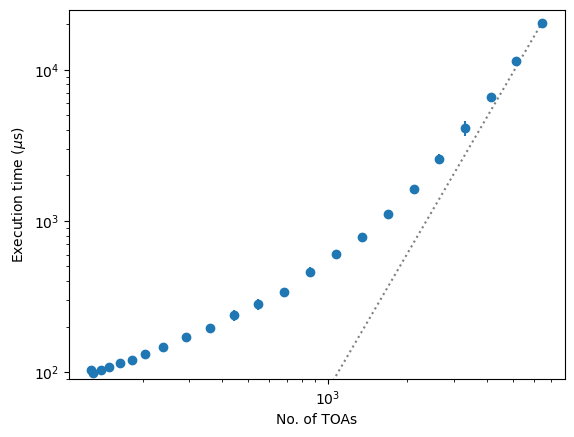

In [12]:
plt.errorbar(perfdata[:, 0], perfdata[:, 1], perfdata[:, 2], ls="", marker="o")
plt.plot(
    perfdata[:, 0],
    perfdata[-1, 1] * (perfdata[:, 0] / perfdata[-1, 0]) ** 3,
    ls="dotted",
    color="grey",
)
# plt.plot(perfdata[:,0], perfdata[0,1] * (perfdata[:,0]/perfdata[0,0])**.5, ls="dotted", color="grey")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("No. of TOAs")
plt.ylabel("Execution time ($\\mu$s)")
plt.ylim((90, 25e3))

In [9]:
%time sdt.run_mcmc(x0, nsteps_initial=10000, nsteps_mid=1000, nsteps_final=3000)

Iteration 0/21 :: Ntoas = 139


100%|██████████| 10000/10000 [00:22<00:00, 451.82it/s]


Iteration 1/21 :: Ntoas = 150


100%|██████████| 1000/1000 [00:02<00:00, 419.43it/s]


Iteration 2/21 :: Ntoas = 164


...

Iteration 19/21 :: Ntoas = 5170


100%|██████████| 1000/1000 [03:28<00:00,  4.79it/s]


Iteration 20/21 :: Ntoas = 6464


100%|██████████| 3000/3000 [21:12<00:00,  2.36it/s]


CPU times: user 3h 24min 6s, sys: 24.3 s, total: 3h 24min 30s
Wall time: 32min 50s


In [10]:
chains = sdt.get_chains()

In [11]:
nchains = len(chains)

In [12]:
full_chain = np.concatenate(chains, axis=0)

In [13]:
samples_raw = sdt.get_final_chain(flat=True, discard=2000, thin=10)

In [14]:
samples = spnta.rescale_samples(samples_raw)

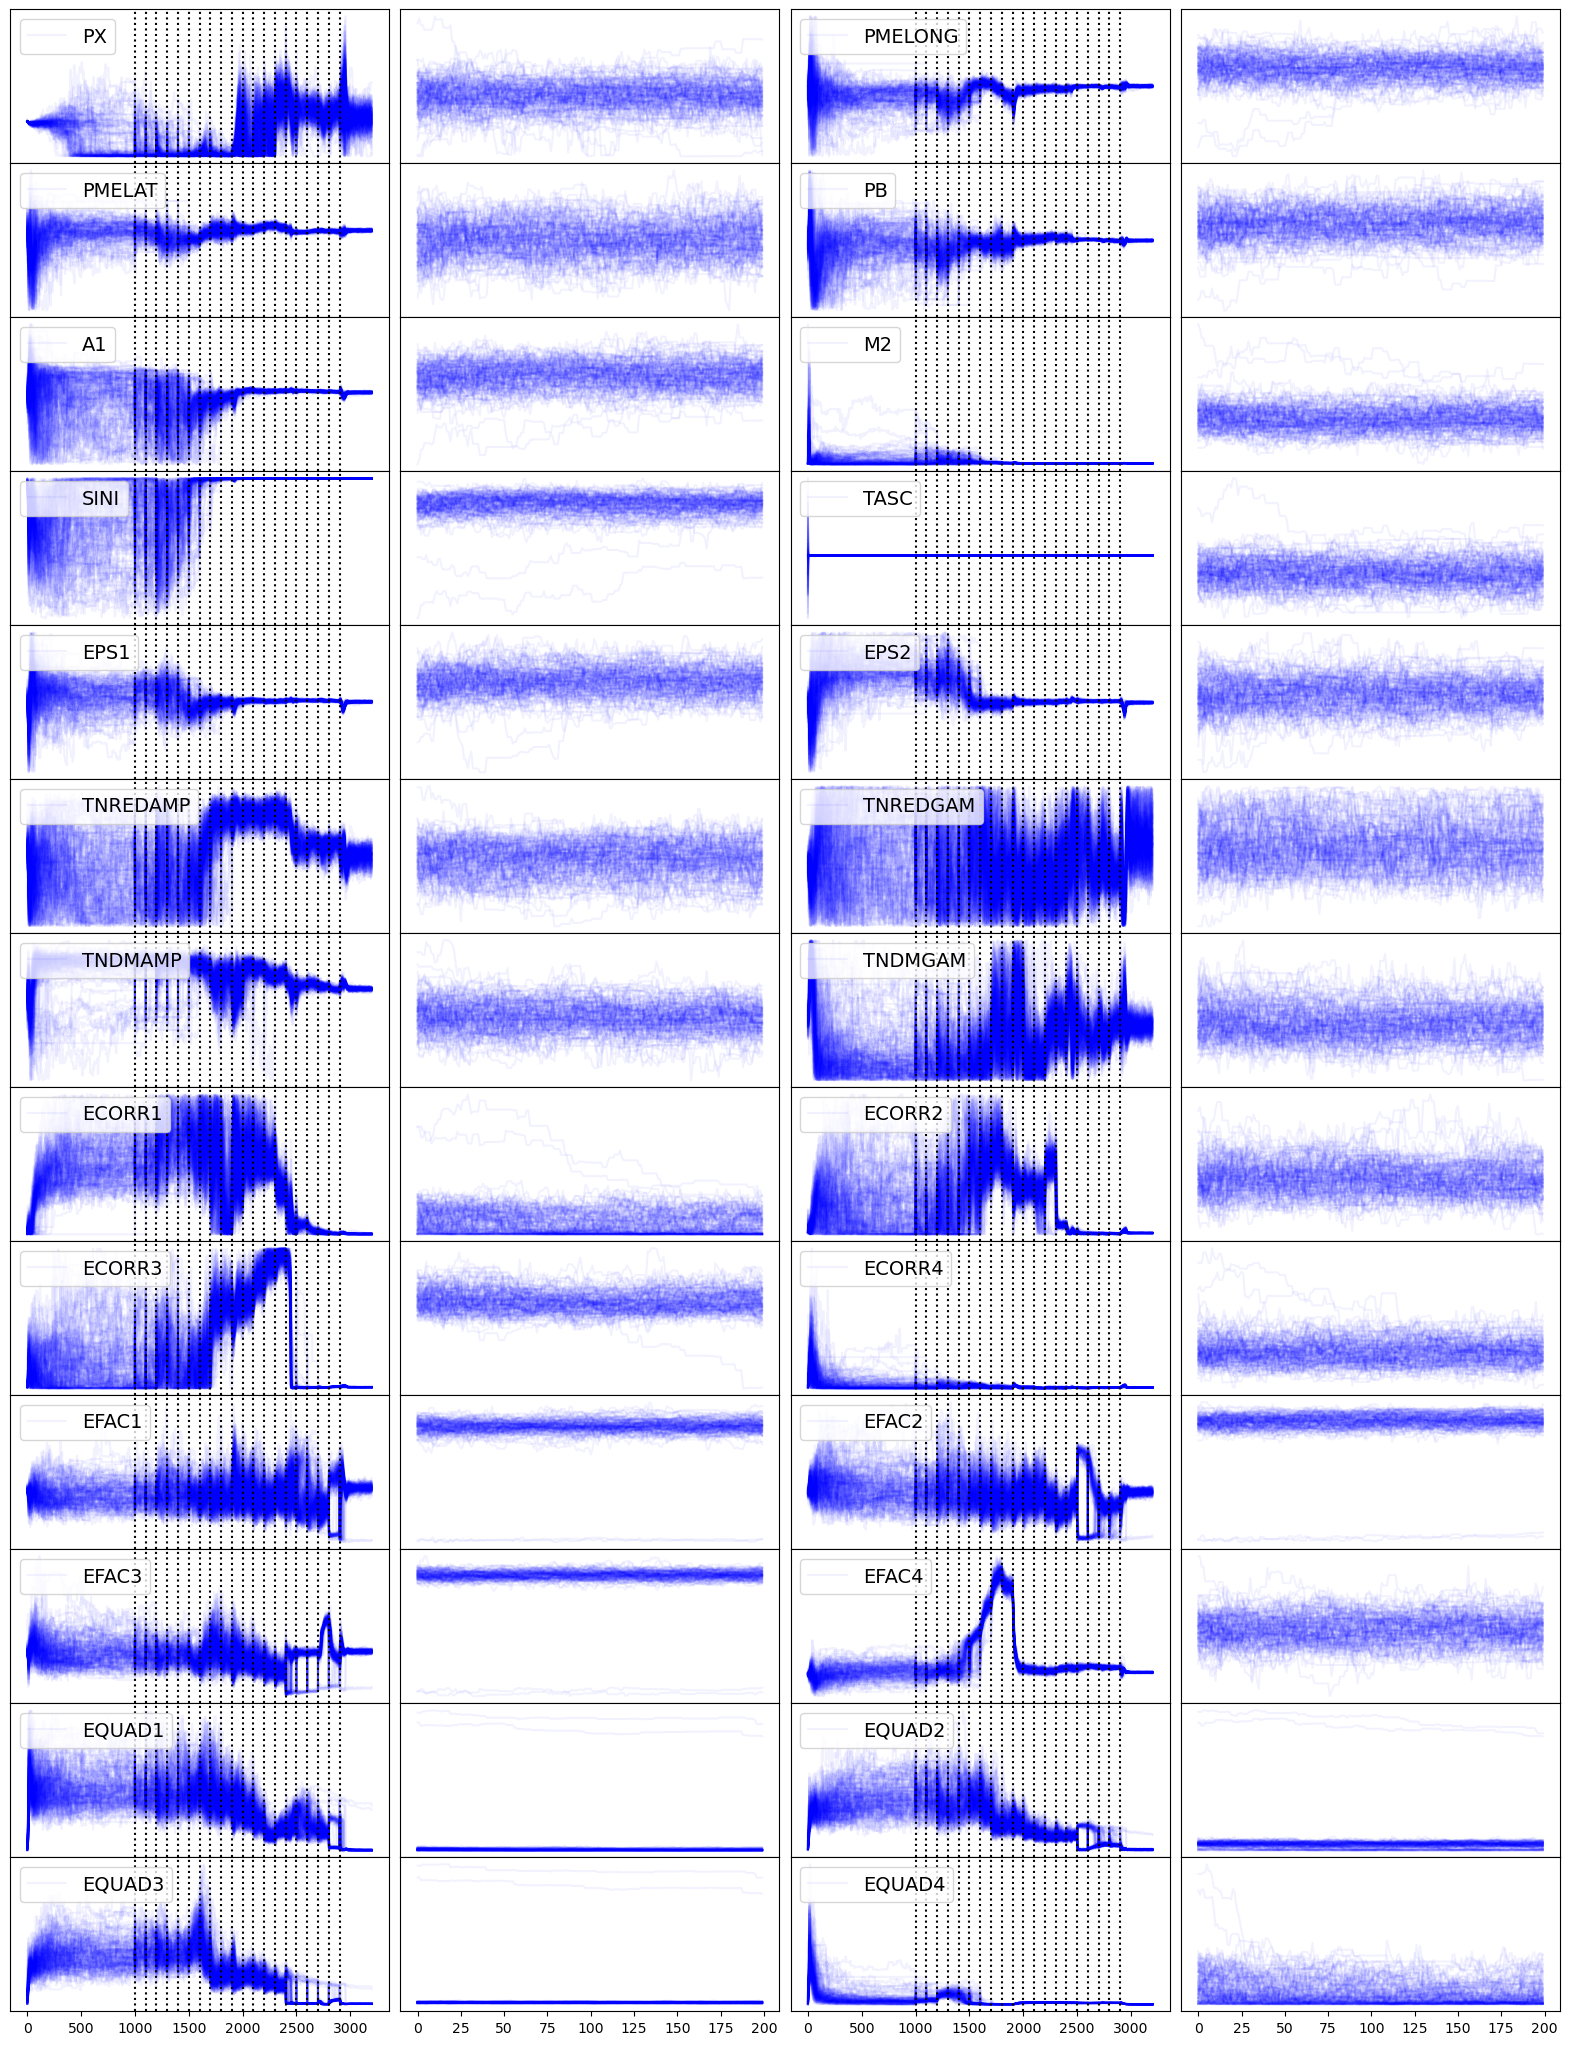

In [15]:
plt.figure(figsize=(20, spnta.ndim))
for ipar, pname in enumerate(spnta.param_names):
    plt.subplot(spnta.ndim // 2, 4, 2 * ipar + 1)
    for w in range(sdt.nwalkers):
        # if w%3==0:
        plt.plot(
            full_chain[:, w, ipar],
            color="blue",
            alpha=0.05,
            label=(pname if w == 0 else None),
        )
    for ww in np.cumsum([chain.shape[0] for chain in chains])[:-1]:
        plt.axvline(ww, color="black", ls="dotted")
    plt.yticks([])
    if ipar not in [len(spnta.param_names) - 1, len(spnta.param_names) - 2]:
        plt.xticks([])
    plt.legend(loc="upper left", fontsize=14)
    # plt.ylabel(pname)

    plt.subplot(spnta.ndim // 2, 4, 2 * ipar + 2)
    for w in range(sdt.nwalkers):
        plt.plot(full_chain[-200:, w, ipar], color="blue", alpha=0.05)
    plt.yticks([])
    if ipar not in [len(spnta.param_names) - 1, len(spnta.param_names) - 2]:
        plt.xticks([])

plt.subplots_adjust(wspace=0.03, hspace=0)
plt.savefig("sdt-out.png")

In [20]:
outdir = "B1855+09_NANOGrav_12yv4_out"

if not os.path.isdir(outdir):
    os.mkdir(outdir)

spnta.save_pre_analysis_summary(outdir)

In [21]:
spnta.save_results(outdir, samples_raw)

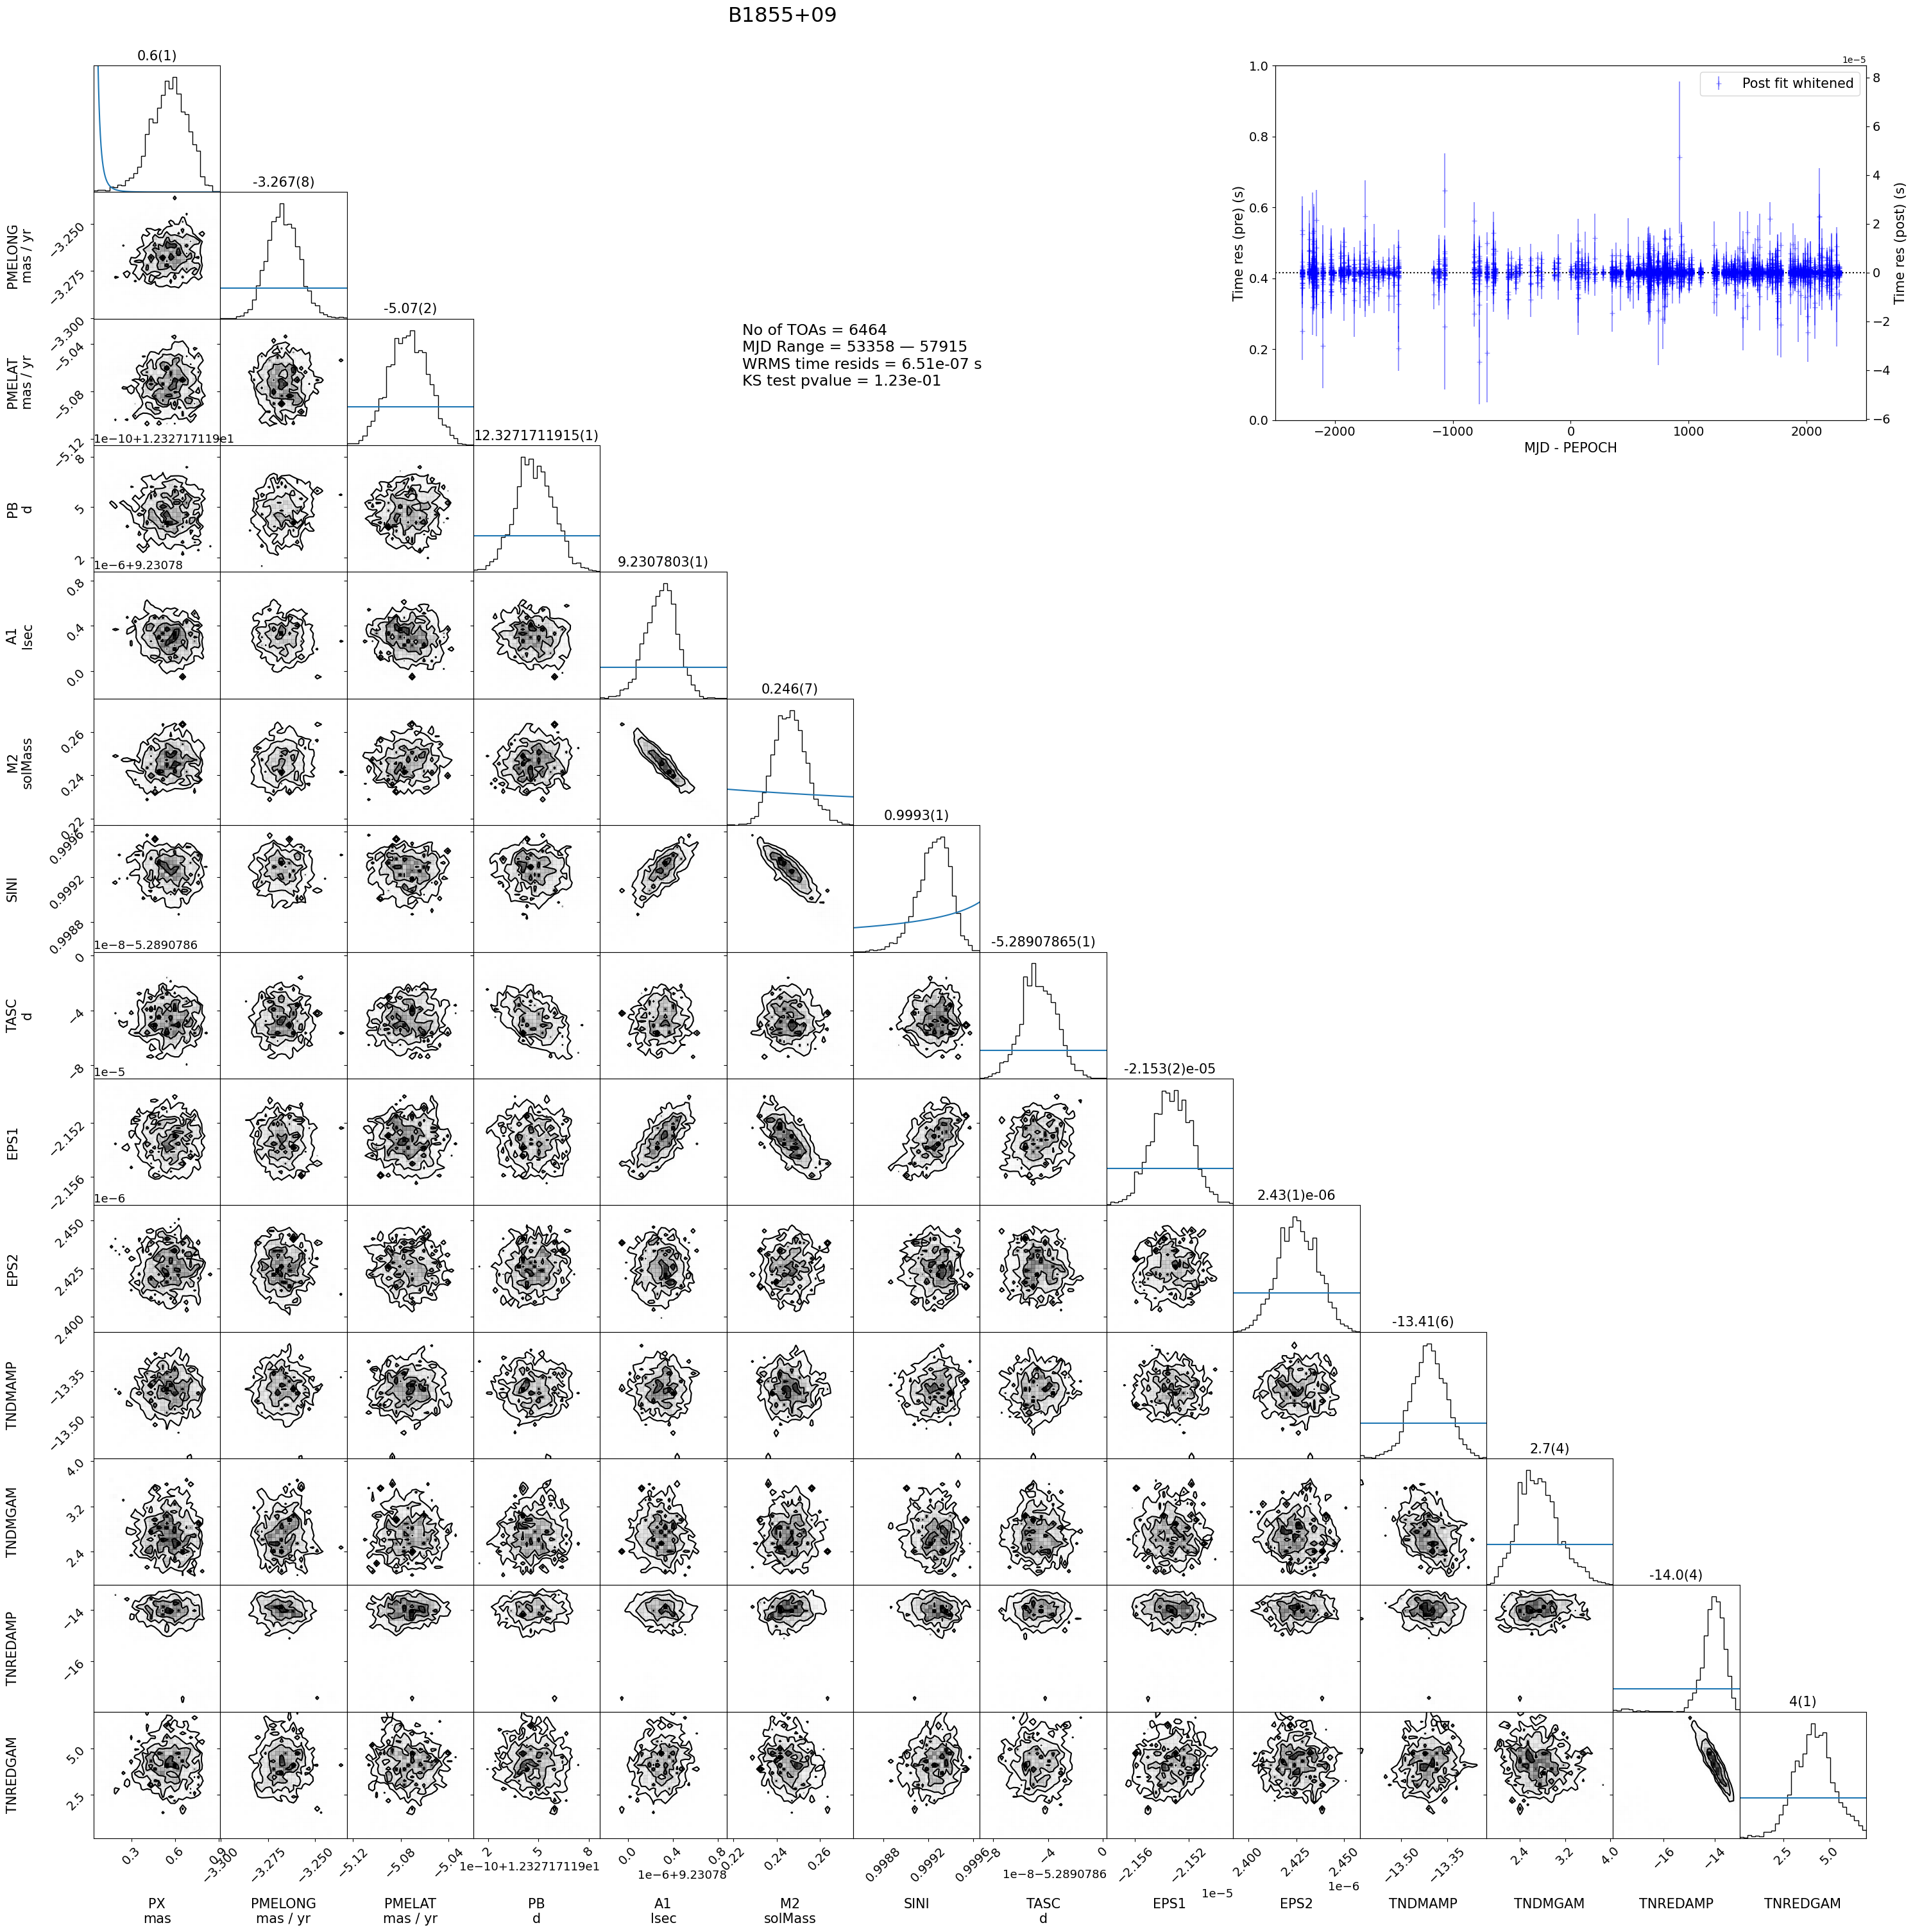

In [22]:
outdir = "B1855+09_NANOGrav_12yv4_out"
pyvela_plot.plot(
    outdir,
    ignore_params=["EFAC", "EQUAD", "ECORR"],
    plot_priors=True,
    labelsize=15,
    labelpad=0.17,
)

In [23]:
burnin = 1000
Neff = (
    (sdt.final_sampler.chain.shape[1] - burnin)
    / np.max(sdt.final_sampler.get_autocorr_time(discard=burnin, tol=10, quiet=True))
    * sdt.nwalkers
)
print(f"Effective number of samples = {Neff}")

Effective number of samples = 1513.4467313701277
